In [1]:
# 1. Start the Session if not running already:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# Initialize Spark with the Postgres driver
spark = SparkSession.builder \
    .appName("LA-Crime-Income") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/05 07:38:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/05 07:38:38 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [2]:
from pyspark.sql import functions as F
from pyspark.sql.functions import col


df = spark.read.parquet("CS226_project/LA_Crime_Income_Merged_Final_parquet")

# income to numeric if needed
if "med_hh_income_num" not in df.columns and "med_hh_income" in df.columns:
    df = df.withColumn(
        "med_hh_income_num",
        F.regexp_replace(F.regexp_replace(col("med_hh_income"), "[$,]", ""), " ", "").cast("double")
    )

# keep only rows with SPA and income available
df = df.filter(col("spa").isNotNull())

In [3]:
# Build SPA level mapping
spa_tbl = df.groupBy("spa").agg(
    F.count("*").alias("crime_count"),
    F.avg("med_hh_income_num").alias("avg_income"),
    F.avg("Vict_Age").alias("avg_victim_age"),
    F.avg(F.when(col("Weapon_Used_Cd").isNotNull(), 1).otherwise(0)).alias("weapon_rate")
).na.drop()

In [4]:
# Correlation analysis:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd

assembler = VectorAssembler(
    inputCols=["crime_count", "avg_income", "avg_victim_age", "weapon_rate"],
    outputCol="features"
)
vec = assembler.transform(spa_tbl)

corr = Correlation.corr(vec, "features", "pearson").head()[0].toArray()



cols = ["crime_count", "avg_income", "avg_victim_age", "weapon_rate"]
corr_df = pd.DataFrame(corr, columns=cols, index=cols)
print(corr_df)

26/03/05 07:38:56 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors
26/03/05 07:39:03 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


                crime_count  avg_income  avg_victim_age  weapon_rate
crime_count        1.000000    0.006595        0.534033    -0.360737
avg_income         0.006595    1.000000        0.843515    -0.934650
avg_victim_age     0.534033    0.843515        1.000000    -0.973242
weapon_rate       -0.360737   -0.934650       -0.973242     1.000000


26/03/05 07:39:03 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


# MLlib Regression: 
Predict crime_count using income + demographics.

This is more meaningful than “SPA vs crime correlation” because SPA is categorical.

In [11]:
ml_tbl = (df
  .filter(col("spa").isNotNull())
  .groupBy("spa", "Occured_Year", "Occured_Month")
  .agg(
      F.count("*").alias("crime_count"),
      F.avg("med_hh_income_num").alias("avg_income"),
      F.avg("Vict_Age").alias("avg_victim_age"),
      F.avg(F.when(col("Weapon_Used_Cd").isNotNull(), 1).otherwise(0)).alias("weapon_rate")
  )
  .na.drop()
)

print("Rows =", ml_tbl.count())
ml_tbl.show(5)

Rows = 248


+--------------------+------------+-------------+-----------+------------------+------------------+------------------+
|                 spa|Occured_Year|Occured_Month|crime_count|        avg_income|    avg_victim_age|       weapon_rate|
+--------------------+------------+-------------+-----------+------------------+------------------+------------------+
|       SPA 6 - South|        2021|            9|     592410| 61994.00816326531|37.132340777502066|0.5628618693134823|
|        SPA 5 - West|        2022|           12|     505992|126750.21628422561|40.599037138927095|0.2723521320495186|
|       SPA 4 - Metro|        2024|            3|     527160| 77295.09748827608| 37.27356020942408|0.2879581151832461|
|SPA 2 - San Fernando|        2021|           10|    1913260|100981.62662999125| 41.14475920679887|0.3430594900849858|
|SPA 2 - San Fernando|        2021|            2|    1423292|100981.62662999127|40.801980198019805|0.3351104341203351|
+--------------------+------------+-------------

In [12]:
# Pipeline for ML model + Regularization

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

spa_indexer = StringIndexer(inputCol="spa", outputCol="spa_idx", handleInvalid="keep")
spa_ohe = OneHotEncoder(inputCols=["spa_idx"], outputCols=["spa_ohe"])

assembler = VectorAssembler(
    inputCols=["spa_ohe", "avg_income", "avg_victim_age", "weapon_rate", "Occured_Month", "Occured_Year"],
    outputCol="features"
)

# Add regularization to avoid singular matrix
lr = LinearRegression(
    featuresCol="features",
    labelCol="crime_count",
    regParam=0.1,          # try 0.01, 0.1, 1.0
    elasticNetParam=0.0    # 0.0=ridge, 1.0=lasso
)

pipe = Pipeline(stages=[spa_indexer, spa_ohe, assembler, lr])

train, test = ml_tbl.randomSplit([0.8, 0.2], seed=42)
model = pipe.fit(train)
pred = model.transform(test)

rmse = RegressionEvaluator(labelCol="crime_count", predictionCol="prediction", metricName="rmse").evaluate(pred)
r2 = RegressionEvaluator(labelCol="crime_count", predictionCol="prediction", metricName="r2").evaluate(pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 297215.9306659704
R2: 0.7870543921718488


In [17]:
lr_model = model.stages[-1]

#print("Coefficients: \n", lr_model.coefficients)
#print("Intercept:", lr_model.intercept)

# output the coefficients for each feature:
feature_names = [
    "SPA_1",
    "SPA_2",
    "SPA_3",
    "SPA_4",
    "avg_income",
    "avg_victim_age",
    "weapon_rate",
    "Occured_Month",
    "Occured_Year"
]

coef = lr_model.coefficients.toArray()
coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
})

coef_table



,Feature,Coefficient
0,SPA_1,130030.209441
1,SPA_2,-328665.359638
2,SPA_3,-429003.586966
3,SPA_4,675469.327843
4,avg_income,-0.343613
5,avg_victim_age,54453.520245
6,weapon_rate,964931.636787
7,Occured_Month,-6917.887834
8,Occured_Year,-21862.953155


In [ ]:
# sort by absolute value of coefficient to see which features are most important:
coef_table["abs_coef"] = coef_table["Coefficient"].abs()
coef_table.sort_values("abs_coef", ascending=False)

,Feature,Coefficient,abs_coef
6,weapon_rate,964931.636787,964931.636787
3,SPA_4,675469.327843,675469.327843
2,SPA_3,-429003.586966,429003.586966
1,SPA_2,-328665.359638,328665.359638
0,SPA_1,130030.209441,130030.209441
5,avg_victim_age,54453.520245,54453.520245
8,Occured_Year,-21862.953155,21862.953155
7,Occured_Month,-6917.887834,6917.887834
4,avg_income,-0.343613,0.343613


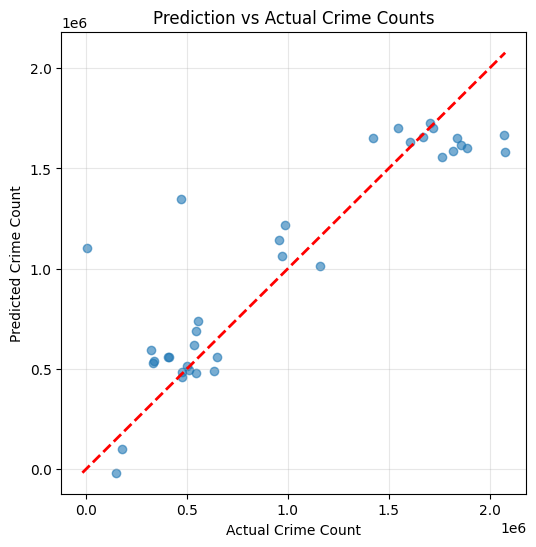

In [16]:
pdf = pred.select("crime_count","prediction").toPandas()

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

# Scatter plot
plt.scatter(pdf["crime_count"], pdf["prediction"], alpha=0.6)

# Diagonal reference line (perfect predictions)
min_val = min(pdf["crime_count"].min(), pdf["prediction"].min())
max_val = max(pdf["crime_count"].max(), pdf["prediction"].max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Prediction vs Actual Crime Counts")

plt.grid(alpha=0.3)
plt.show()

# Geospatial crime clustering with Spark MLlib K-Means (LAT/LON)

In [8]:
# the hotspot analysis - we can use the same grid-based approach as before, but now we can also incorporate the crime counts and income levels to identify hotspots more effectively.
grid_scale = 500  # 200/500/1000

df_geo = (df
    .withColumn("LAT_d", col("LAT").cast("double"))
    .withColumn("LON_d", col("LON").cast("double"))
    .filter(col("LAT_d").between(33.5, 34.5) & col("LON_d").between(-119.0, -117.0))
    .select("LAT_d","LON_d")
    .na.drop()
)

df_grid = (df_geo
    .withColumn("lat_grid", F.floor(col("LAT_d") * grid_scale) / grid_scale)
    .withColumn("lon_grid", F.floor(col("LON_d") * grid_scale) / grid_scale)
)

cells = (df_grid
    .groupBy("lat_grid","lon_grid")
    .count()
    .orderBy(F.desc("count"))
)

In [9]:
Kcells = 20000  # top cells only
cells_top = cells.limit(Kcells)

In [10]:
# Assemble features + run KMeans

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

assembler = VectorAssembler(inputCols=["lat_grid","lon_grid"], outputCol="features")
X = assembler.transform(cells_top)

k = 8
kmeans = KMeans(k=k, seed=42, featuresCol="features")
km_model = kmeans.fit(X)

pred = km_model.transform(X)

evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette", distanceMeasure="squaredEuclidean")
sil = evaluator.evaluate(pred)
print("Silhouette =", sil)

Silhouette = 0.5502079822786655


In [11]:
cluster_summary = (pred
    .groupBy("prediction")
    .agg(
        F.count("*").alias("num_cells"),
        F.sum("count").alias("total_crimes_in_cells"),
        F.avg("lat_grid").alias("center_lat"),
        F.avg("lon_grid").alias("center_lon")
    )
    .orderBy(F.desc("total_crimes_in_cells"))
)

cluster_summary.show(truncate=False)

+----------+---------+---------------------+------------------+-------------------+
|prediction|num_cells|total_crimes_in_cells|center_lat        |center_lon         |
+----------+---------+---------------------+------------------+-------------------+
|2         |3516     |55064575             |34.083241183162656|-118.24873720136479|
|3         |3017     |43992297             |33.99153861451765 |-118.2995280079551 |
|5         |3289     |35825452             |34.20675402858021 |-118.5852934022494 |
|0         |2252     |27579053             |34.16439342806397 |-118.46407904085245|
|1         |2606     |26239304             |34.26841366078287 |-118.47183806600152|
|6         |3259     |17634239             |34.03392513040796 |-118.42769438478048|
|7         |1629     |9551725              |34.22134192756289 |-118.36101534683849|
|4         |432      |198307               |33.777625000000015|-118.2870879629629 |
+----------+---------+---------------------+------------------+-------------

In [23]:
# Silhouette scores for different k values:
scores = []
for k in [3,4,5,6,7,8,9,10,12]:
    km = KMeans(k=k, seed=42, featuresCol="features")
    m = km.fit(X)
    p = m.transform(X)
    sil = evaluator.evaluate(p)
    scores.append((k, sil))

print(scores)

[(3, 0.5796473829945229), (4, 0.513765029795806), (5, 0.5937618821836109), (6, 0.5782158590318297), (7, 0.5566992321866889), (8, 0.5502079822786655), (9, 0.530573292522373), (10, 0.554128662384816), (12, 0.5723571267713722)]


In [12]:
# plot of clustered hotspot cells (matplotlib)
#Only collect aggregated cells to driver for plotting, not the entire dataset

cluster_counts = (pred
    .groupBy("prediction")
    .agg(F.sum("count").alias("total_crimes"))
    .orderBy("prediction")
)

cluster_pdf = cluster_counts.toPandas()

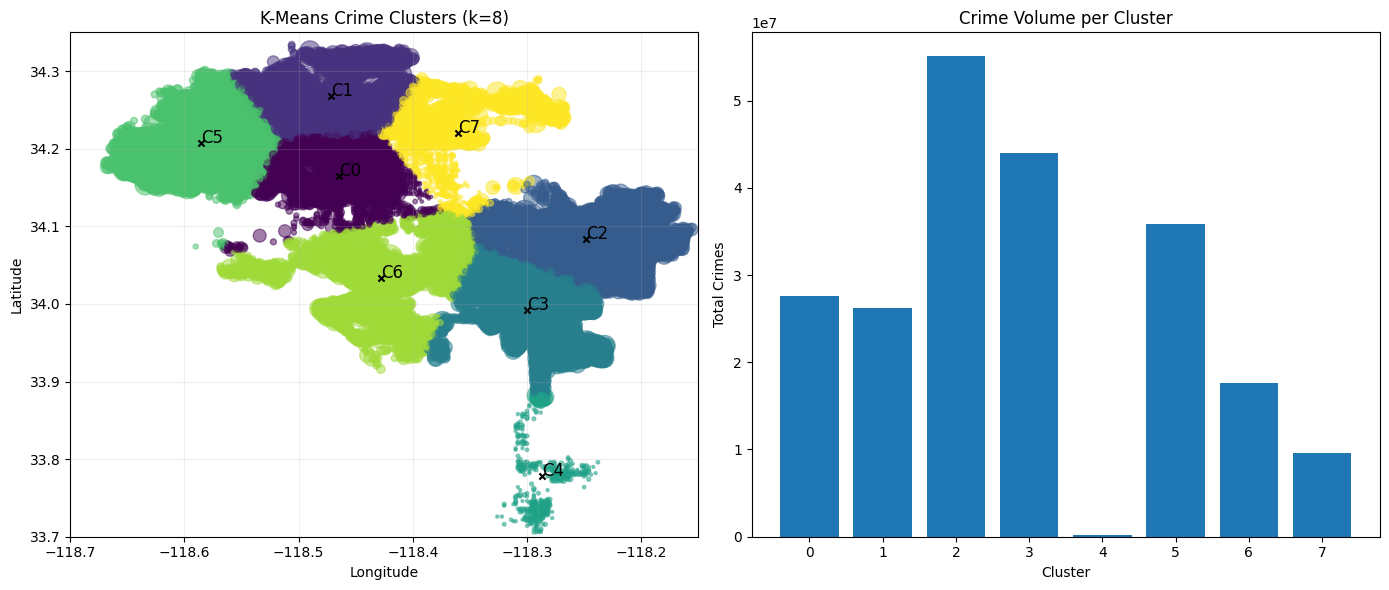

In [13]:
import matplotlib.pyplot as plt
import numpy as np

pdf = pred.select("lon_grid","lat_grid","count","prediction").toPandas()

fig, ax = plt.subplots(1,2, figsize=(14,6))

# ---- Map Plot ----
ax[0].scatter(
    pdf["lon_grid"],
    pdf["lat_grid"],
    s=np.sqrt(pdf["count"]),
    c=pdf["prediction"],
    alpha=0.5
)

ax[0].set_xlabel("Longitude")
ax[0].set_ylabel("Latitude")
ax[0].set_title(f"K-Means Crime Clusters (k={k})")
ax[0].set_xlim(-118.7, -118.15)
ax[0].set_ylim(33.7, 34.35)
ax[0].grid(alpha=0.2)


# ---- Bar Chart ----
ax[1].bar(
    cluster_pdf["prediction"].astype(str),
    cluster_pdf["total_crimes"]
)

ax[1].set_xlabel("Cluster")
ax[1].set_ylabel("Total Crimes")
ax[1].set_title("Crime Volume per Cluster")

centers = np.array(km_model.clusterCenters())

for i, center in enumerate(centers):
    ax[0].scatter(center[1], center[0], marker="x", s=20, color="black")
    ax[0].text(center[1], center[0], f"C{i}", fontsize=12, color="black")


plt.tight_layout()
plt.show()

In [14]:
cluster_summary = (pred
    .groupBy("prediction")
    .agg(
        F.sum("count").alias("total_crimes"),
        F.avg("lat_grid").alias("center_lat"),
        F.avg("lon_grid").alias("center_lon")
    )
    .orderBy(F.desc("total_crimes"))
)

cluster_summary.show()

+----------+------------+------------------+-------------------+
|prediction|total_crimes|        center_lat|         center_lon|
+----------+------------+------------------+-------------------+
|         2|    55064575|34.083241183162656|-118.24873720136479|
|         3|    43992297| 33.99153861451765| -118.2995280079551|
|         5|    35825452| 34.20675402858021| -118.5852934022494|
|         0|    27579053| 34.16439342806397|-118.46407904085245|
|         1|    26239304| 34.26841366078287|-118.47183806600152|
|         6|    17634239| 34.03392513040796|-118.42769438478048|
|         7|     9551725| 34.22134192756289|-118.36101534683849|
|         4|      198307|33.777625000000015| -118.2870879629629|
+----------+------------+------------------+-------------------+



In [15]:
spark.range(1).count()

1

In [17]:
from pyspark.sql.functions import col, floor, count as Fcount

# Grid + SPA level aggregation
grid_scale = 500

df_spa_cells = (df
    .withColumn("LAT_d", col("LAT").cast("double"))
    .withColumn("LON_d", col("LON").cast("double"))
    .withColumn("lat_grid", floor(col("LAT_d") * grid_scale) / grid_scale)
    .withColumn("lon_grid", floor(col("LON_d") * grid_scale) / grid_scale)
    .select("lat_grid","lon_grid","spa")
    .na.drop()
    .groupBy("lat_grid","lon_grid","spa")
    .agg(Fcount("*").alias("n"))
)

In [18]:
# Dominant SPA per grid:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

w = Window.partitionBy("lat_grid","lon_grid").orderBy(F.desc("n"))

cell_to_spa = (df_spa_cells
    .withColumn("rn", F.row_number().over(w))
    .filter(col("rn") == 1)
    .select("lat_grid","lon_grid", col("spa").alias("cell_spa"))
)

In [19]:
from pyspark.sql.functions import sum as Fsum

cluster_spa = (pred
    .join(cell_to_spa, ["lat_grid","lon_grid"], "left")
    .groupBy("prediction", "cell_spa")
    .agg(Fsum("count").alias("spa_crimes"))
    .orderBy("prediction", F.desc("spa_crimes"))
)
cluster_spa.show(50, truncate=False)

+----------+--------------------+----------+
|prediction|cell_spa            |spa_crimes|
+----------+--------------------+----------+
|0         |SPA 2 - San Fernando|27324170  |
|0         |SPA 5 - West        |249195    |
|0         |Other               |5688      |
|1         |SPA 2 - San Fernando|26239304  |
|2         |SPA 4 - Metro       |48916127  |
|2         |SPA 5 - West        |6125352   |
|2         |Other               |23096     |
|3         |SPA 6 - South       |31107269  |
|3         |SPA 4 - Metro       |10184382  |
|3         |SPA 5 - West        |2690669   |
|3         |Other               |9977      |
|4         |SPA 6 - South       |175913    |
|4         |Other               |22394     |
|5         |SPA 2 - San Fernando|35815360  |
|5         |SPA 5 - West        |10092     |
|6         |SPA 5 - West        |16946783  |
|6         |SPA 6 - South       |687456    |
|7         |SPA 2 - San Fernando|9394685   |
|7         |SPA 5 - West        |92994     |
|7        

In [20]:
# Max SPA per cluster:
w2 = Window.partitionBy("prediction").orderBy(F.desc("spa_crimes"))

max_spa_per_cluster = (cluster_spa
    .withColumn("rn", F.row_number().over(w2))
    .filter(col("rn") == 1)
    .select(
        col("prediction").alias("cluster"),
        col("cell_spa").alias("top_spa"),
        "spa_crimes"
    )
    .orderBy("cluster")
)

max_spa_per_cluster.show(truncate=False)

+-------+--------------------+----------+
|cluster|top_spa             |spa_crimes|
+-------+--------------------+----------+
|0      |SPA 2 - San Fernando|27324170  |
|1      |SPA 2 - San Fernando|26239304  |
|2      |SPA 4 - Metro       |48916127  |
|3      |SPA 6 - South       |31107269  |
|4      |SPA 6 - South       |175913    |
|5      |SPA 2 - San Fernando|35815360  |
|6      |SPA 5 - West        |16946783  |
|7      |SPA 2 - San Fernando|9394685   |
+-------+--------------------+----------+

